<a href="https://www.kaggle.com/code/lalit7881/global-sti-insights-hiv-gonorrhea-syphilis-eda?scriptVersionId=313762496" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/global-sti-intelligence-hivgonorrhea-syphilis/global_sti_intelligence_hiv_gonorrhea_syphilis.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/global-sti-intelligence-hivgonorrhea-syphilis/global_sti_intelligence_hiv_gonorrhea_syphilis.csv")

In [3]:
df.head()

,record_id,disease,disease_type,disease_treatment,is_curable,indicator_code,metric,country_code,country_alpha2,country_name,...,ci_width,burden_tier,value_prev_year,yoy_change_abs,yoy_change_pct,yoy_direction,data_source,source_url,scrape_date,dataset_version
0,dc8e8a7ad9ec74,Gonorrhea,Bacterial,Antibiotics,1,GASP_ISOLATESDSR_PROPORTION,Antimicrobial resistance or decreased suscepti...,ARG,AR,Argentina,...,NaN,MEDIUM,NaN,NaN,NaN,STABLE,WHO Global Health Observatory (GHO) OData API,https://ghoapi.azureedge.net/api,2026-04-22,v1.0
1,b3729e3e819a34,Gonorrhea,Bacterial,Antibiotics,1,GASP_ISOLATESDSR_PROPORTION,Antimicrobial resistance or decreased suscepti...,AUS,AU,Australia,...,NaN,MEDIUM,100.0,-99.97,-99.97,DECREASING,WHO Global Health Observatory (GHO) OData API,https://ghoapi.azureedge.net/api,2026-04-22,v1.0
2,639a14cf9f0da5,Gonorrhea,Bacterial,Antibiotics,1,GASP_ISOLATESDSR_PROPORTION,Antimicrobial resistance or decreased suscepti...,AUT,AT,Austria,...,NaN,MEDIUM,200.0,-178.85,-89.42,DECREASING,WHO Global Health Observatory (GHO) OData API,https://ghoapi.azureedge.net/api,2026-04-22,v1.0
3,73f4cbddee0f8a,Gonorrhea,Bacterial,Antibiotics,1,GASP_ISOLATESDSR_PROPORTION,Antimicrobial resistance or decreased suscepti...,BEL,BE,Belgium,...,NaN,MEDIUM,500.0,-500.00,-100.00,DECREASING,WHO Global Health Observatory (GHO) OData API,https://ghoapi.azureedge.net/api,2026-04-22,v1.0
4,bd99bbc1b9cdfd,Gonorrhea,Bacterial,Antibiotics,1,GASP_ISOLATESDSR_PROPORTION,Antimicrobial resistance or decreased suscepti...,BHR,BH,Bahrain,...,NaN,MEDIUM,500.0,-500.00,-100.00,DECREASING,WHO Global Health Observatory (GHO) OData API,https://ghoapi.azureedge.net/api,2026-04-22,v1.0


In [4]:
df.tail()

,record_id,disease,disease_type,disease_treatment,is_curable,indicator_code,metric,country_code,country_alpha2,country_name,...,ci_width,burden_tier,value_prev_year,yoy_change_abs,yoy_change_pct,yoy_direction,data_source,source_url,scrape_date,dataset_version
67433,5567ecce1ff94d,Syphilis,Bacterial,Penicillin,1,PerctestedANC,Women accessing antenatal care (ANC) services ...,VEN,VE,"Venezuela, Bolivarian Republic of",...,NaN,LOW,90.6,-26.1,-28.81,DECREASING,WHO Global Health Observatory (GHO) OData API,https://ghoapi.azureedge.net/api,2026-04-22,v1.0
67434,fa03c54c916fa1,Syphilis,Bacterial,Penicillin,1,PerctestedANC,Women accessing antenatal care (ANC) services ...,VUT,VU,Vanuatu,...,NaN,LOW,55.8,-5.4,-9.68,DECREASING,WHO Global Health Observatory (GHO) OData API,https://ghoapi.azureedge.net/api,2026-04-22,v1.0
67435,08b0012954a506,Syphilis,Bacterial,Penicillin,1,PerctestedANC,Women accessing antenatal care (ANC) services ...,ZAF,ZA,South Africa,...,NaN,MEDIUM,85.4,-1.5,-1.76,DECREASING,WHO Global Health Observatory (GHO) OData API,https://ghoapi.azureedge.net/api,2026-04-22,v1.0
67436,b2e43d73c9c75a,Syphilis,Bacterial,Penicillin,1,PerctestedANC,Women accessing antenatal care (ANC) services ...,ZMB,ZM,Zambia,...,NaN,MEDIUM,93.5,-0.4,-0.43,DECREASING,WHO Global Health Observatory (GHO) OData API,https://ghoapi.azureedge.net/api,2026-04-22,v1.0
67437,81877ebbd3f063,Syphilis,Bacterial,Penicillin,1,PerctestedANC,Women accessing antenatal care (ANC) services ...,ZWE,ZW,Zimbabwe,...,NaN,MEDIUM,94.4,0.9,0.95,INCREASING,WHO Global Health Observatory (GHO) OData API,https://ghoapi.azureedge.net/api,2026-04-22,v1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67438 entries, 0 to 67437
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   record_id          67438 non-null  object 
 1   disease            67438 non-null  object 
 2   disease_type       67438 non-null  object 
 3   disease_treatment  67438 non-null  object 
 4   is_curable         67438 non-null  int64  
 5   indicator_code     67438 non-null  object 
 6   metric             67438 non-null  object 
 7   country_code       67438 non-null  object 
 8   country_alpha2     66996 non-null  object 
 9   country_name       67438 non-null  object 
 10  who_region         67438 non-null  object 
 11  year               67438 non-null  int64  
 12  decade             67438 non-null  object 
 13  is_recent          67438 non-null  int64  
 14  years_ago          67438 non-null  int64  
 15  sex                7027 non-null   object 
 16  sex_label          674

In [6]:
df.describe()

,is_curable,year,is_recent,years_ago,value,value_low,value_high,ci_width,value_prev_year,yoy_change_abs,yoy_change_pct
count,67438.000000,67438.000000,67438.000000,67438.000000,6.743800e+04,4.480300e+04,4.478900e+04,4.478900e+04,6.359600e+04,6.359600e+04,63539.000
mean,0.117248,2012.729173,0.227705,13.270827,2.127223e+04,1.692951e+04,2.247788e+04,5.543092e+03,1.993858e+04,1.431929e+03,inf
std,0.321718,7.531076,0.419355,7.531076,4.747272e+05,1.660127e+05,1.986632e+05,3.744229e+04,3.243201e+05,5.845951e+05,NaN
min,0.000000,1990.000000,0.000000,2.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.123780e+07,-100.080
25%,0.000000,2007.000000,0.000000,7.000000,2.500000e+00,1.000000e+00,2.000000e+00,1.000000e-01,7.844975e-01,-8.770250e+01,-96.790
50%,0.000000,2013.000000,0.000000,13.000000,5.700000e+01,4.300000e+01,7.500000e+01,1.000000e+01,3.200000e+01,1.390000e+00,55.040
75%,0.000000,2019.000000,0.000000,19.000000,3.400000e+02,7.200000e+02,1.400000e+03,5.000000e+02,2.000000e+02,1.150000e+02,11532.135
max,1.000000,2024.000000,1.000000,36.000000,6.671178e+07,7.200000e+06,8.500000e+06,1.300000e+06,6.123780e+07,6.671128e+07,inf


In [7]:
df.isnull().sum()

record_id                0
disease                  0
disease_type             0
disease_treatment        0
is_curable               0
indicator_code           0
metric                   0
country_code             0
country_alpha2         442
country_name             0
who_region               0
year                     0
decade                   0
is_recent                0
years_ago                0
sex                  60411
sex_label                0
value                    0
value_low            22635
value_high           22649
value_display            0
ci_width             22649
burden_tier              0
value_prev_year       3842
yoy_change_abs        3842
yoy_change_pct        3899
yoy_direction            0
data_source              0
source_url               0
scrape_date              0
dataset_version          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['record_id', 'disease', 'disease_type', 'disease_treatment',
       'is_curable', 'indicator_code', 'metric', 'country_code',
       'country_alpha2', 'country_name', 'who_region', 'year', 'decade',
       'is_recent', 'years_ago', 'sex', 'sex_label', 'value', 'value_low',
       'value_high', 'value_display', 'ci_width', 'burden_tier',
       'value_prev_year', 'yoy_change_abs', 'yoy_change_pct', 'yoy_direction',
       'data_source', 'source_url', 'scrape_date', 'dataset_version'],
      dtype='object')

In [10]:
df.dtypes

record_id             object
disease               object
disease_type          object
disease_treatment     object
is_curable             int64
indicator_code        object
metric                object
country_code          object
country_alpha2        object
country_name          object
who_region            object
year                   int64
decade                object
is_recent              int64
years_ago              int64
sex                   object
sex_label             object
value                float64
value_low            float64
value_high           float64
value_display         object
ci_width             float64
burden_tier           object
value_prev_year      float64
yoy_change_abs       float64
yoy_change_pct       float64
yoy_direction         object
data_source           object
source_url            object
scrape_date           object
dataset_version       object
dtype: object

In [11]:
df.shape


(67438, 31)

In [12]:
df.nunique()

record_id            67438
disease                  3
disease_type             2
disease_treatment        3
is_curable               2
indicator_code          40
metric                  40
country_code           200
country_alpha2         198
country_name           200
who_region               7
year                    35
decade                   4
is_recent                2
years_ago               35
sex                      8
sex_label                1
value                 4415
value_low             1061
value_high            1424
value_display        25865
ci_width              2062
burden_tier              4
value_prev_year       4629
yoy_change_abs       27209
yoy_change_pct       17416
yoy_direction            3
data_source              1
source_url               1
scrape_date              1
dataset_version          1
dtype: int64

## EDA

        record_id    disease disease_type disease_treatment  is_curable  \
0  dc8e8a7ad9ec74  Gonorrhea    Bacterial       Antibiotics           1   
1  b3729e3e819a34  Gonorrhea    Bacterial       Antibiotics           1   
2  639a14cf9f0da5  Gonorrhea    Bacterial       Antibiotics           1   
3  73f4cbddee0f8a  Gonorrhea    Bacterial       Antibiotics           1   
4  bd99bbc1b9cdfd  Gonorrhea    Bacterial       Antibiotics           1   

                indicator_code  \
0  GASP_ISOLATESDSR_PROPORTION   
1  GASP_ISOLATESDSR_PROPORTION   
2  GASP_ISOLATESDSR_PROPORTION   
3  GASP_ISOLATESDSR_PROPORTION   
4  GASP_ISOLATESDSR_PROPORTION   

                                              metric country_code  \
0  Antimicrobial resistance or decreased suscepti...          ARG   
1  Antimicrobial resistance or decreased suscepti...          AUS   
2  Antimicrobial resistance or decreased suscepti...          AUT   
3  Antimicrobial resistance or decreased suscepti...          BEL   

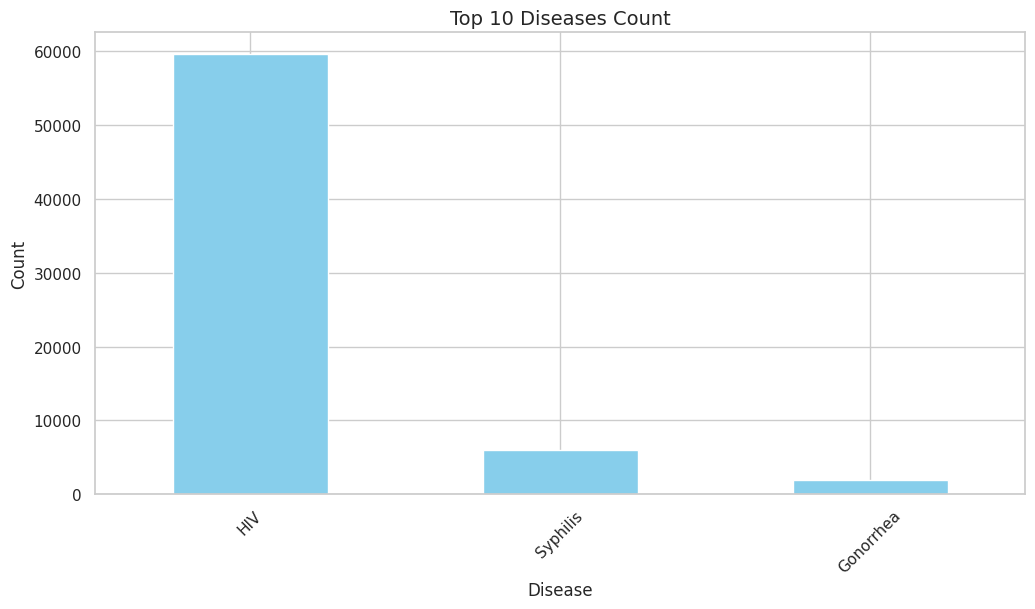

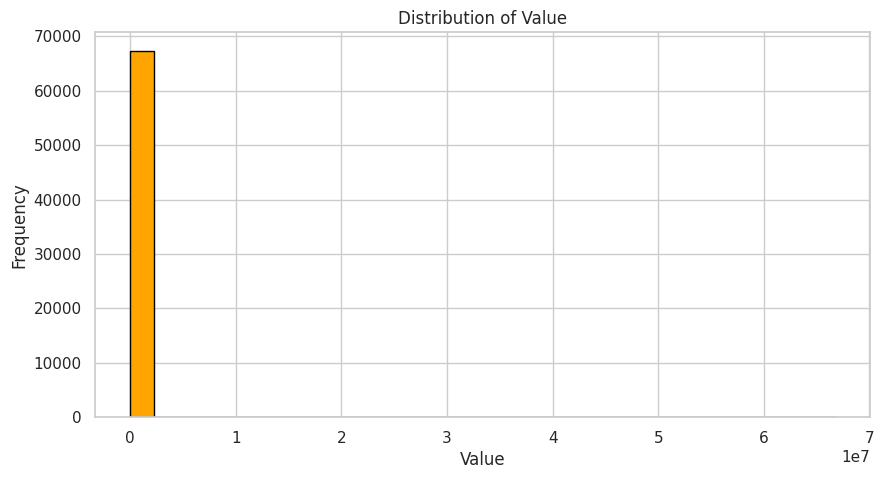

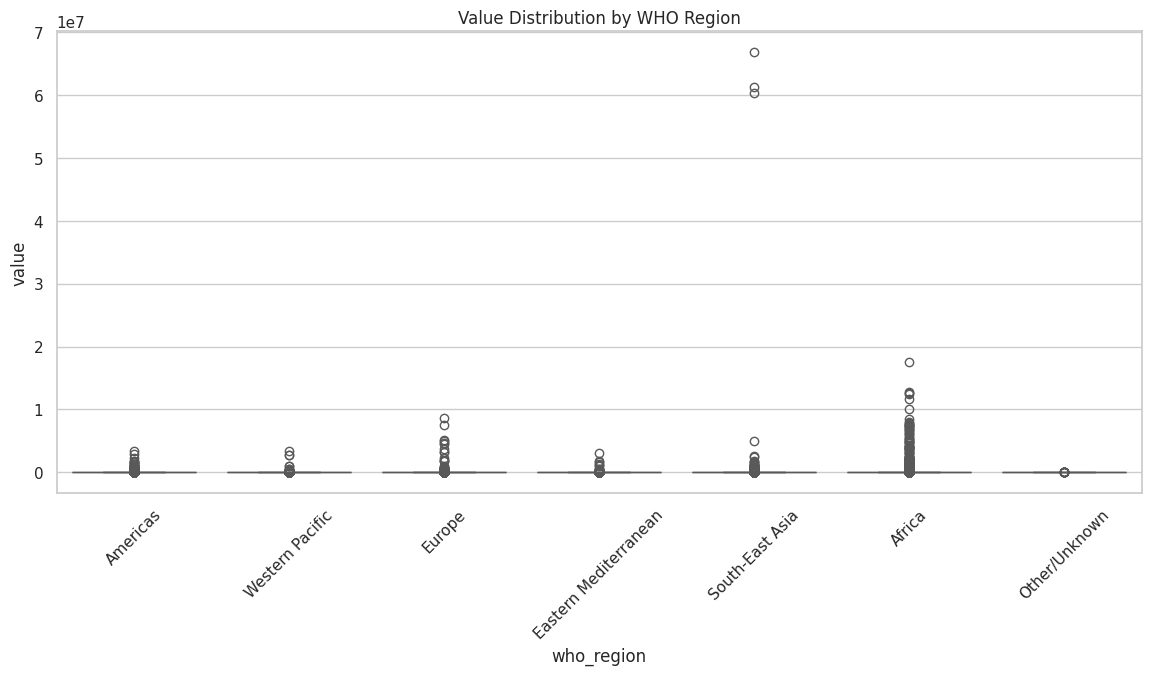

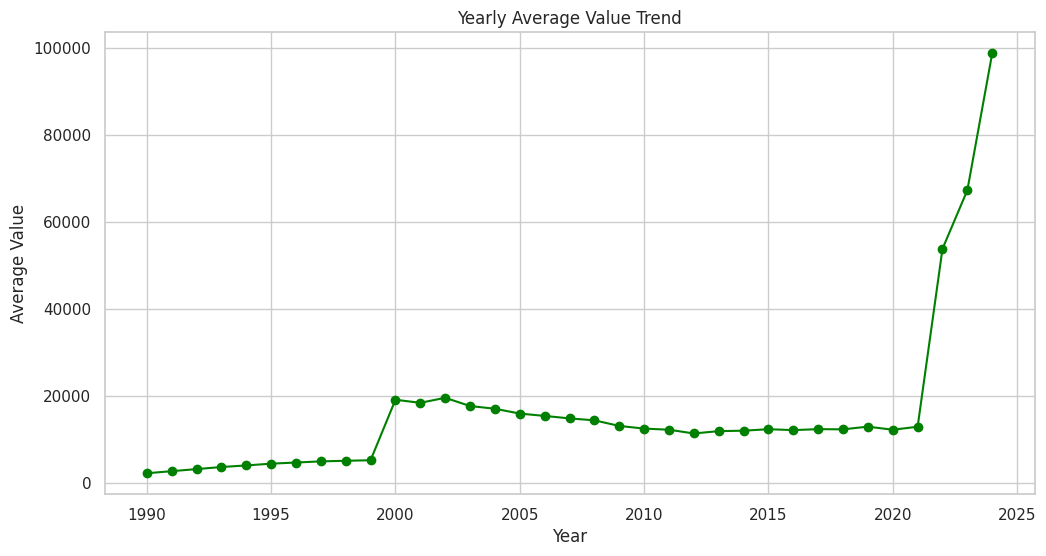

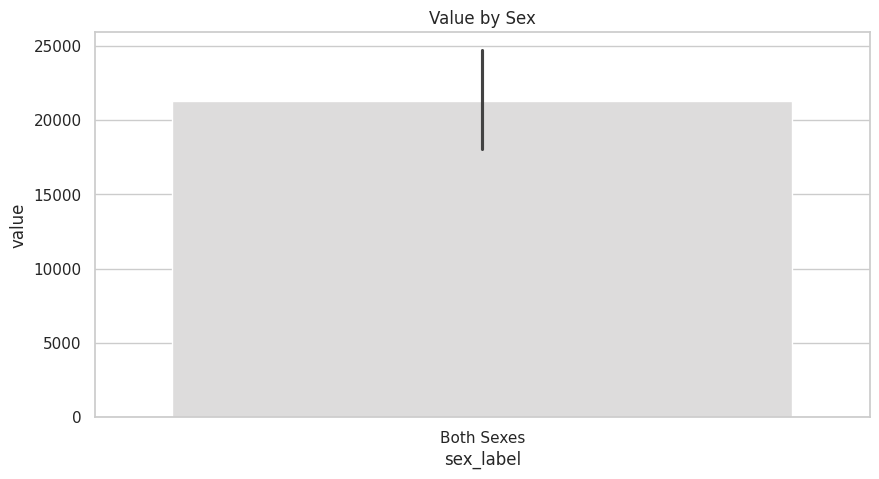

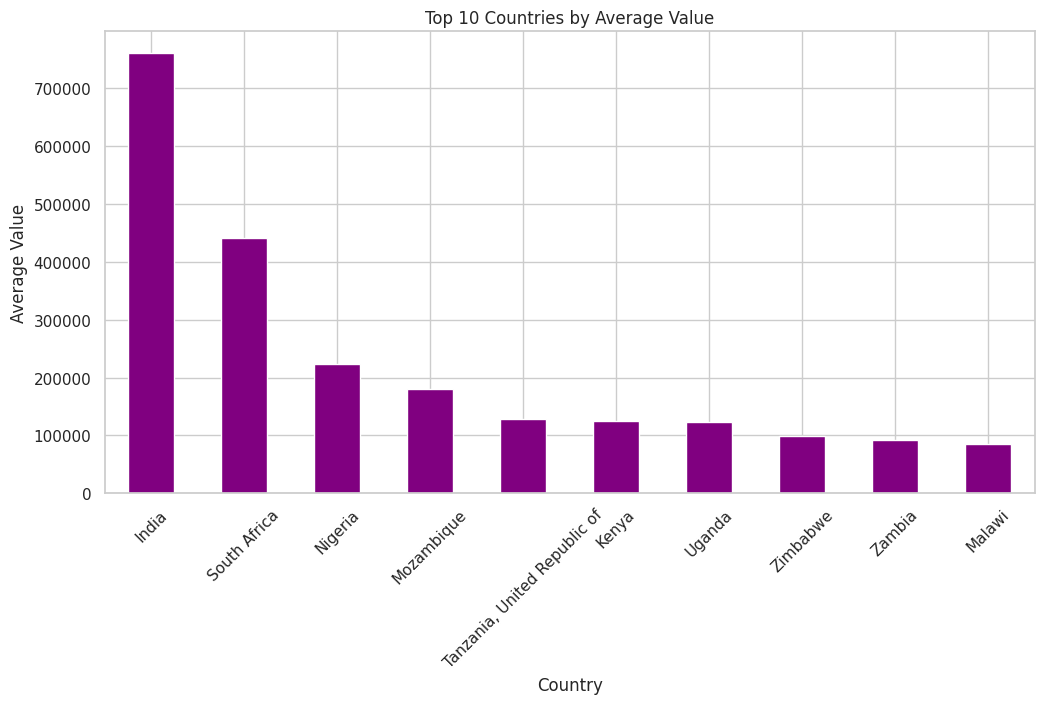

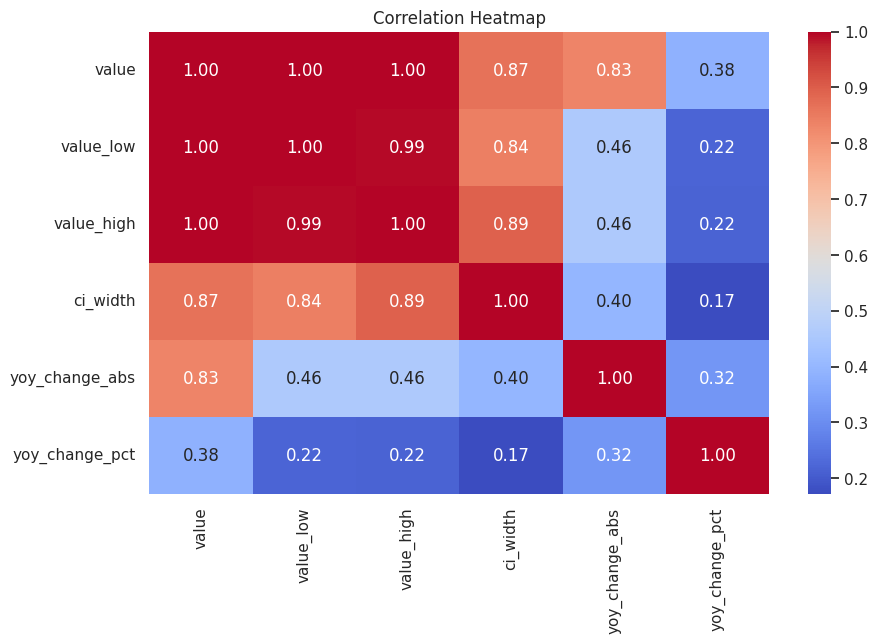

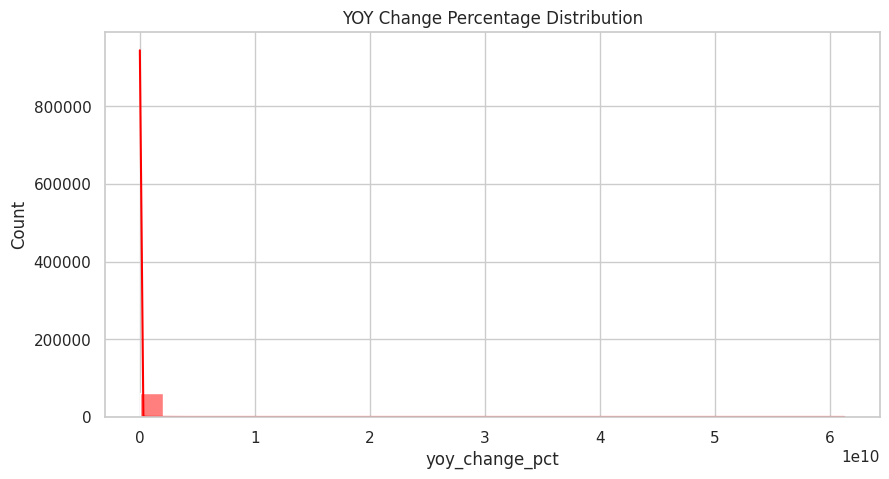

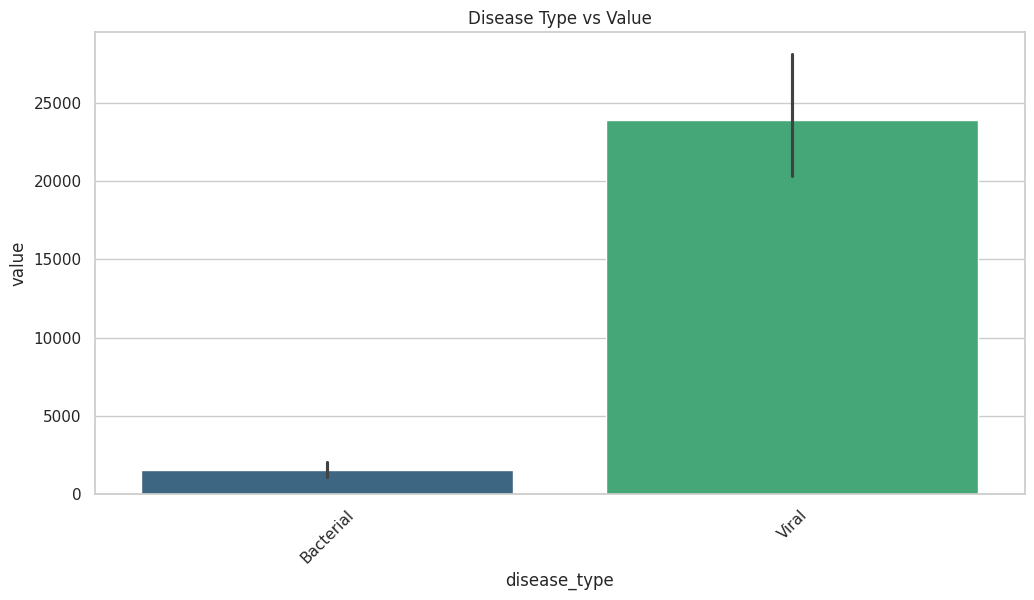

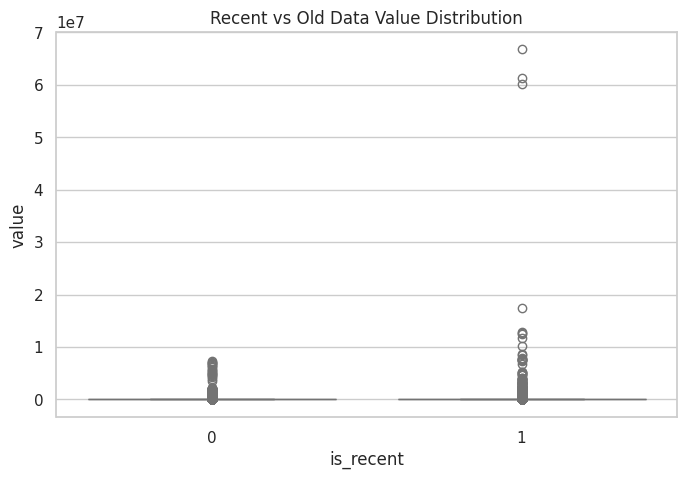

In [13]:
# Set style
sns.set(style="whitegrid")

# ================================
# BASIC DATA CHECK
# ================================
print(df.head())
print(df.info())

# Convert year to numeric if needed
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# ================================
# 1. DISEASE COUNT DISTRIBUTION
# ================================
plt.figure(figsize=(12,6))
df['disease'].value_counts().head(10).plot(
    kind='bar',
    color='skyblue'
)
plt.title("Top 10 Diseases Count", fontsize=14)
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# ================================
# 2. VALUE DISTRIBUTION (HISTOGRAM)
# ================================
plt.figure(figsize=(10,5))
plt.hist(df['value'].dropna(), bins=30, color='orange', edgecolor='black')
plt.title("Distribution of Value")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

# ================================
# 3. VALUE BY WHO REGION (BOXPLOT)
# ================================
plt.figure(figsize=(14,6))
sns.boxplot(
    x='who_region',
    y='value',
    data=df,
    palette='Set2'
)
plt.title("Value Distribution by WHO Region")
plt.xticks(rotation=45)
plt.show()

# ================================
# 4. YEARLY TREND (LINE PLOT)
# ================================
yearly_avg = df.groupby('year')['value'].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(
    yearly_avg['year'],
    yearly_avg['value'],
    marker='o',
    color='green'
)
plt.title("Yearly Average Value Trend")
plt.xlabel("Year")
plt.ylabel("Average Value")
plt.grid(True)
plt.show()

# ================================
# 5. SEX-WISE COMPARISON
# ================================
plt.figure(figsize=(10,5))
sns.barplot(
    x='sex_label',
    y='value',
    data=df,
    palette='coolwarm'
)
plt.title("Value by Sex")
plt.show()

# ================================
# 6. TOP COUNTRIES BY VALUE
# ================================
top_countries = df.groupby('country_name')['value'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_countries.plot(
    kind='bar',
    color='purple'
)
plt.title("Top 10 Countries by Average Value")
plt.xlabel("Country")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.show()

# ================================
# 7. HEATMAP (CORRELATION)
# ================================
plt.figure(figsize=(10,6))
corr = df[['value', 'value_low', 'value_high', 'ci_width', 
           'yoy_change_abs', 'yoy_change_pct']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

# ================================
# 8. YOY CHANGE DISTRIBUTION
# ================================
plt.figure(figsize=(10,5))
sns.histplot(
    df['yoy_change_pct'].dropna(),
    bins=30,
    kde=True,
    color='red'
)
plt.title("YOY Change Percentage Distribution")
plt.show()

# ================================
# 9. DISEASE TYPE VS VALUE
# ================================
plt.figure(figsize=(12,6))
sns.barplot(
    x='disease_type',
    y='value',
    data=df,
    palette='viridis'
)
plt.title("Disease Type vs Value")
plt.xticks(rotation=45)
plt.show()

# ================================
# 10. RECENT VS OLD DATA
# ================================
plt.figure(figsize=(8,5))
sns.boxplot(
    x='is_recent',
    y='value',
    data=df,
    palette='pastel'
)
plt.title("Recent vs Old Data Value Distribution")
plt.show()

## Feature engineering


========== Logistic Regression ==========
Accuracy: 0.6220

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.64      0.63      6724
           1       0.63      0.61      0.62      6764

    accuracy                           0.62     13488
   macro avg       0.62      0.62      0.62     13488
weighted avg       0.62      0.62      0.62     13488



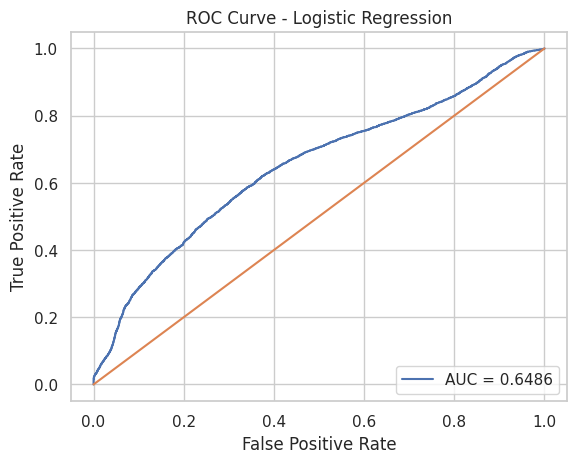


========== Decision Tree ==========
Accuracy: 0.9640

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      6724
           1       0.97      0.96      0.96      6764

    accuracy                           0.96     13488
   macro avg       0.96      0.96      0.96     13488
weighted avg       0.96      0.96      0.96     13488



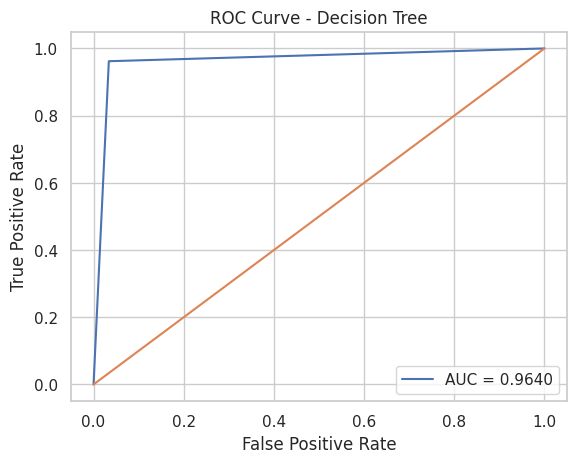


========== Random Forest ==========
Accuracy: 0.9577

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      6724
           1       0.96      0.96      0.96      6764

    accuracy                           0.96     13488
   macro avg       0.96      0.96      0.96     13488
weighted avg       0.96      0.96      0.96     13488



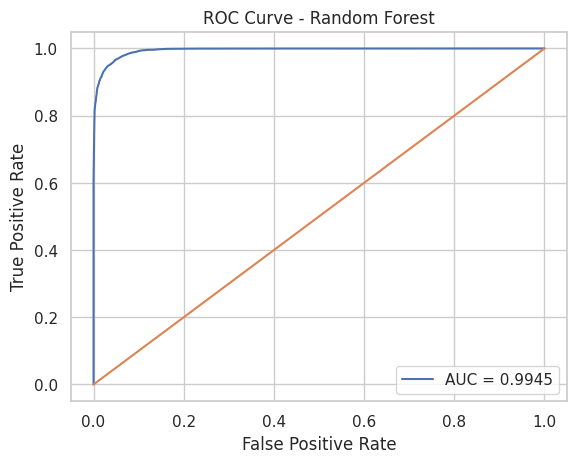

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


# ================================
# COPY DATA (AVOID MODIFYING ORIGINAL)
# ================================
data = df.copy()

# ================================
# TARGET CREATION (NO LEAKAGE)
# ================================
median_value = data['value'].median()
data['target'] = (data['value'] >= median_value).astype(int)

# ================================
# DROP LEAKAGE COLUMNS
# ================================
leak_cols = [
    'value', 'value_low', 'value_high', 'value_display',
    'value_prev_year', 'yoy_change_abs', 'yoy_change_pct'
]
data = data.drop(columns=leak_cols, errors='ignore')

# ================================
# SELECT FEATURES
# ================================
features = [
    'disease', 'disease_type', 'is_curable',
    'indicator_code', 'metric', 'country_name',
    'who_region', 'year', 'decade', 'sex_label',
    'burden_tier'
]

data = data[features + ['target']]

# ================================
# HANDLE MISSING VALUES
# ================================
data = data.dropna()

# ================================
# TRAIN TEST SPLIT
# ================================
X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# LABEL ENCODING (NO LEAKAGE)
# ================================
categorical_cols = X_train.select_dtypes(include='object').columns

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    
    # Fit ONLY on train
    X_train[col] = le.fit_transform(X_train[col])
    
    # Handle unseen labels in test
    X_test[col] = X_test[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
    
    encoders[col] = le

# ================================
# FEATURE SCALING (NUMERIC ONLY)
# ================================
scaler = StandardScaler()

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# ================================
# MODELS
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

# ================================
# TRAIN + EVALUATE
# ================================
for name, model in models.items():
    print(f"\n========== {name} ==========")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # ================================
    # ROC CURVE
    # ================================
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1], [0,1])  # diagonal line
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend(loc="lower right")
    plt.show()

## Thank you...pls upvote!!!!!!!!!!